In [1]:
!pip install numpy pandas matplotlib open3d

Import Libraries



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import open3d as o3d

In [3]:
def read_kitti_pc(file_path):
    pc = np.fromfile(file_path, dtype=np.float32).reshape(-1, 4)
    return pc

LiDAR shot visualisation


In [ ]:
velo_file = "data/velodyne_points/data/0000000000.bin"  

point_cloud = read_kitti_pc(velo_file)

pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(point_cloud[:, :3])

print(point_cloud)

o3d.visualization.draw_geometries([pcd])

[[73.042  8.921  2.697  0.   ]
 [72.9    9.136  2.694  0.   ]
 [72.863  9.364  2.693  0.   ]
 ...
 [ 3.694 -1.397 -1.726  0.31 ]
 [ 3.715 -1.392 -1.734  0.48 ]
 [ 3.706 -1.381 -1.728  0.   ]]


GNSS + IMU download

In [ ]:
oxts_path = "data/oxts/data/"  

files = sorted(glob.glob(oxts_path + "*.txt"))

data = []

for f in files:
    values = list(map(float, open(f).read().split()))
    data.append(values)

data = np.array(data)

print("Shape:", data.shape)

Shape: (481, 30)


In [7]:
lat = data[:,0]
lon = data[:,1]

ax = data[:,11]
ay = data[:,12]
az = data[:,13]

Coordanates to meters 

In [8]:
R = 6371000

def haversine(lat1, lon1, lat2, lon2):
    
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2*np.arctan2(np.sqrt(a), np.sqrt(1-a))

    return R*c

Distance computating 

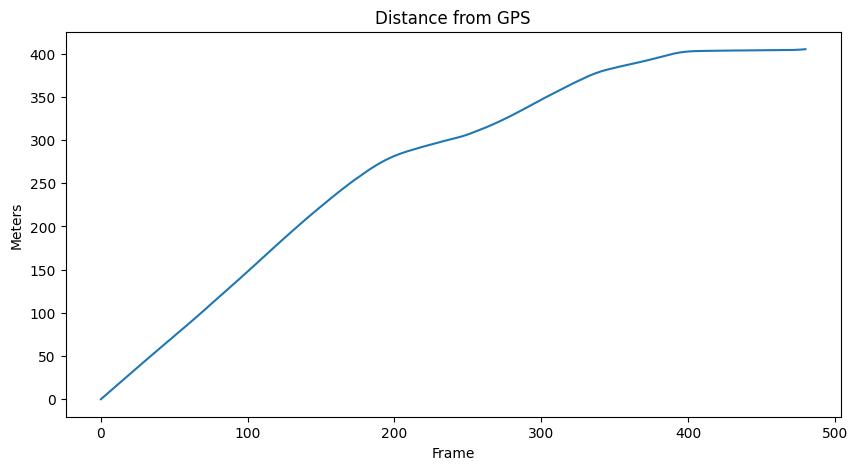

In [9]:
gps_dist = [0]

for i in range(1, len(lat)):
    
    d = haversine(lat[i-1], lon[i-1], lat[i], lon[i])
    
    gps_dist.append(gps_dist[-1] + d)

gps_dist = np.array(gps_dist)

plt.figure(figsize=(10,5))
plt.plot(gps_dist)
plt.title("Distance from GPS")
plt.xlabel("Frame")
plt.ylabel("Meters")
plt.show()

Noise evaluation

In [10]:
static_samples = 100

std_acc = np.std(ax[:static_samples])

print("Accelerometer noise std =", std_acc)

Accelerometer noise std = 0.19286775012401766


In [11]:
std_meas = np.std(gps_dist[:static_samples])

print("GPS noise std =", std_meas)

GPS noise std = 42.467860084290955


Kalman filter parameters

In [12]:
dt = 0.1

A = np.array([
    [1, dt],
    [0, 1]
])

B = np.array([
    [0.5 * dt**2],
    [dt]
])

H = np.array([[1, 0]])

In [13]:
Q = np.array([
    [std_acc**2, 0],
    [0, std_acc**2]
])

R = np.array([[std_meas**2]])

In [14]:
x = np.array([[0],
              [0]])

P = np.eye(2)

kf_positions = []

In [15]:
for i in range(len(gps_dist)):
    
    u = ax[i]
    
    # Prediction
    x = A @ x + B * u
    P = A @ P @ A.T + Q
    
    # Measurement
    z = np.array([[gps_dist[i]]])
    
    # Kalman gain
    S = H @ P @ H.T + R
    K = P @ H.T @ np.linalg.inv(S)
    
    # Update
    y = z - H @ x
    x = x + K @ y
    
    P = (np.eye(2) - K @ H) @ P
    
    kf_positions.append(x[0,0])

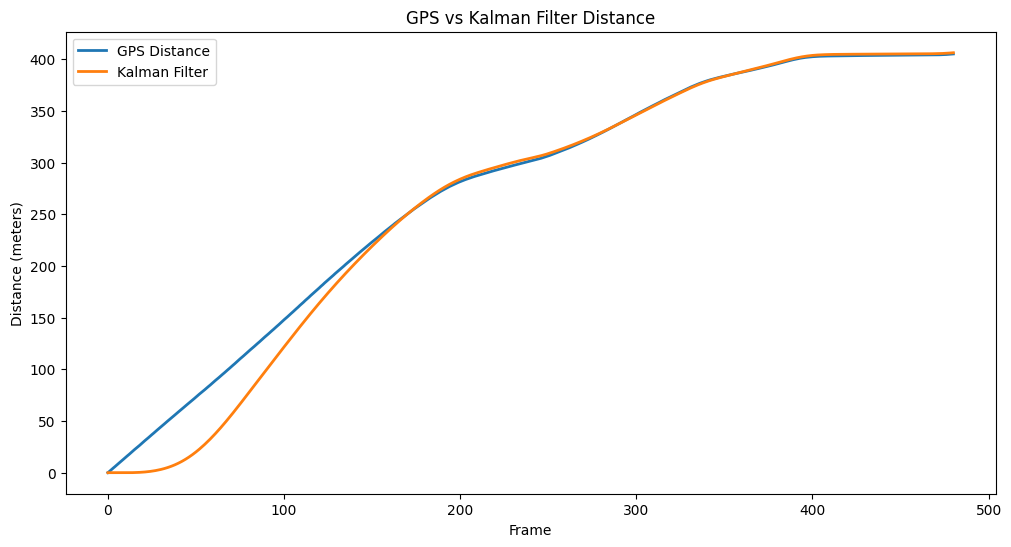

In [16]:
plt.figure(figsize=(12,6))

plt.plot(gps_dist, label="GPS Distance", linewidth=2)
plt.plot(kf_positions, label="Kalman Filter", linewidth=2)

plt.legend()
plt.xlabel("Frame")
plt.ylabel("Distance (meters)")
plt.title("GPS vs Kalman Filter Distance")

plt.show()

In [17]:
df = pd.DataFrame({
    "gps_distance": gps_dist,
    "kf_distance": kf_positions
})

df.to_csv("kf_results.csv", index=False)

print("Saved results to kf_results.csv")

Saved results to kf_results.csv
